In [1]:
import numpy as np
import pandas as pd
'''
Create dataset from the given function.
'''
# Create x values (integers from 0 to 10)
x_data = np.arange(0, 11)  # 11 is exclusive, so this goes 0-10

#  Calculate y values using the function
y_data = np.sin((np.pi / 2) * x_data) + (x_data / 2) # np.sin takes radians, so (np.pi / 2) * x works

# Display as a dataframe to verify
df = pd.DataFrame({'x': x_data, 'y': y_data})
print(df)

     x    y
0    0  0.0
1    1  1.5
2    2  1.0
3    3  0.5
4    4  2.0
5    5  3.5
6    6  3.0
7    7  2.5
8    8  4.0
9    9  5.5
10  10  5.0


In [2]:
import numpy as np
#Create a new set of x values with 10x higher resolution
num_points = len(x_data) * 10
x = np.linspace(x_data.min(), x_data.max(), num_points)

In [3]:
#Define linear interpolation function
def linear_interpolation(x, x_data, y_data):

    #Handle extrapolation
    if x < x_data[0]:
        return y_data[0] # Assumption: Constant value from first point
    if x > x_data[-1]:
        return y_data[-1] # Assumption: Constant value from last point

    #Interpolation
    for i in range(len(x_data) - 1):
        if x_data[i] <= x <= x_data[i+1]:
            ai = (y_data[i+1]-y_data[i])/(x_data[i+1]-x_data[i]) #slope
            bi = y_data[i]

            gi_x = ai*(x-x_data[i]) + bi #y
    return gi_x

In [4]:
from scipy.interpolate import CubicSpline
#create cubic spline intrepolation function
cs = CubicSpline(x_data, y_data)

In [5]:
#interpolated y values
y_ln = [linear_interpolation(x, x_data, y_data) for x in x]
y_cs = cs(x)

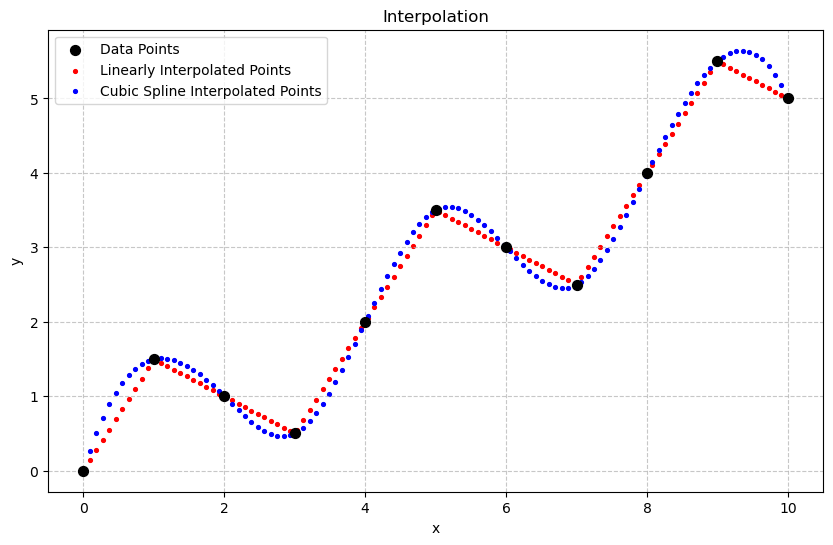

In [6]:
import matplotlib.pyplot as plt
#Plotting
plt.figure(figsize=(10, 6))

# Plot the dataset
plt.scatter(x_data, y_data, color='black', s=50, zorder=5, label='Data Points')

# Plot the linearly interpolated points (and line may be)
plt.scatter(x, y_ln, color='red', s=30, marker='.', label='Linearly Interpolated Points')
#plt.plot(x, y, 'b-', label='Linear Interpolation', alpha=0.6)

# Plot the cubic spline interpolated points (and line)
plt.scatter(x, y_cs, color='blue', s=30, marker='.', label='Cubic Spline Interpolated Points')
#plt.plot(x, y_cs, 'b-', label='Cubic Spline Interpolation', alpha=0.2)

plt.title('Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [8]:
# Calculate the "True" values y for the high-resolution x
y = np.sin((np.pi/2) * x) + (x / 2)
# Calculate Relative Errors
# Formula: (Interpolated - True) / True
# Note: We calculate this, but we will likely see a division by zero warning at x=0
with np.errstate(divide='ignore', invalid='ignore'):
    error_linear = (y_ln - y) / y
    error_cubic  = (y_cs - y) / y

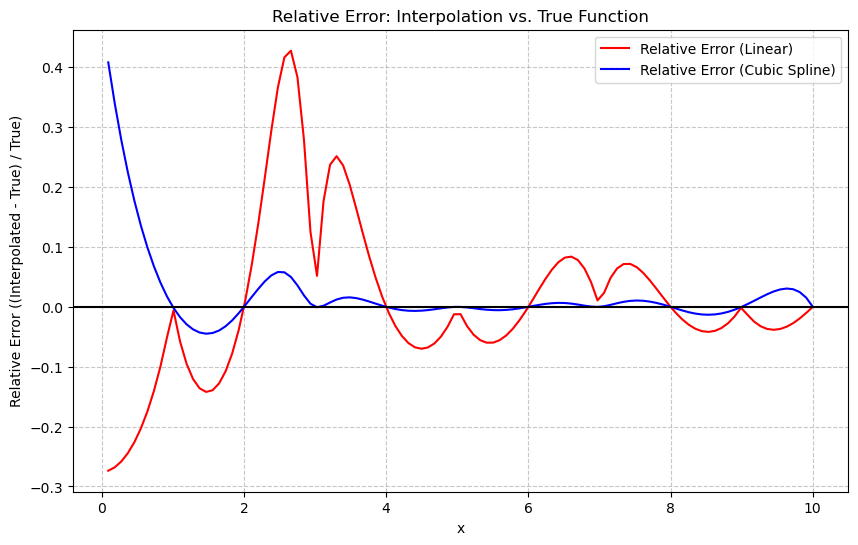

In [9]:
#Plotting
plt.figure(figsize=(10, 6))

# We slice [1:] to skip the first point where x=0 (to avoid the infinity spike)
plt.plot(x[1:], error_linear[1:], 'r-', label='Relative Error (Linear)', linewidth=1.5)
plt.plot(x[1:], error_cubic[1:], 'b-', label='Relative Error (Cubic Spline)', linewidth=1.5)

plt.title('Relative Error: Interpolation vs. True Function')
plt.xlabel('x')
plt.ylabel('Relative Error ((Interpolated - True) / True)')
plt.axhline(0, color='black', linewidth=1.5) # Zero line for reference
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# Comment
* The relative error of Cubic Spline Interpolation is very small compared to Linear Interpolation. This is because straight lines cut the corners of the curved sine wave.
* The relative error picks in the middle of every interval with a distinct periodic pattern. The peaks decrease for higher values of x for linear interpolation.